# Anomaly / Outlier Detection with PyOD

**Project idea:** In many real-world datasets (transactions, sensor readings, network traffic) most records are "normal" and a small fraction are anomalies (fraud, faults, intrusions).

**This notebook:**
1. Builds a synthetic tabular dataset that mimics fraud/outlier detection (mostly normal points + a small % of injected anomalies)
2. Trains **several PyOD detectors** (Isolation Forest, KNN, ECOD, PCA-based) on the same data
3. Scores every point with an anomaly score and flags outliers
4. Evaluates each detector with **ROC-AUC** (ground truth is known here since data is synthetic)
5. Visualizes true anomalies vs. each detector's predicted anomalies

## 1. Setup

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from pyod.utils.data import generate_data
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.ecod import ECOD
from pyod.models.pca import PCA

np.random.seed(42)

## 2. Generate a synthetic "transactions" dataset

In [14]:
CONTAMINATION = 0.1  

X_train, X_test, y_train, y_test = generate_data(
    n_train=400,
    n_test=200,
    n_features=2,          
    contamination=CONTAMINATION,
    random_state=42,
)

print(f"Train set: {X_train.shape[0]} records, {int(y_train.sum())} anomalies")
print(f"Test set:  {X_test.shape[0]} records, {int(y_test.sum())} anomalies")

Train set: 400 records, 40 anomalies
Test set:  200 records, 20 anomalies


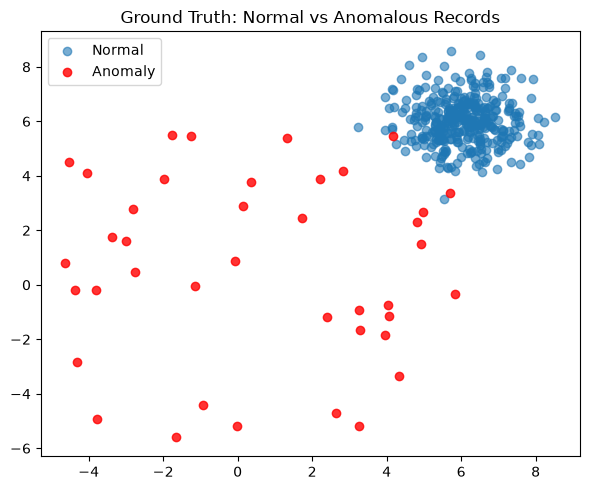

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label="Normal", alpha=0.6)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="Anomaly", color="red", alpha=0.8)
plt.title("Ground Truth: Normal vs Anomalous Records")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Train multiple anomaly detectors

Different algorithms "mine" outliers differently:
- **Isolation Forest** — isolates points via random splits; anomalies get isolated faster
- **KNN** — a point is anomalous if it's far from its nearest neighbors
- **ECOD** — empirical cumulative distribution based, no hyperparameters, very fast
- **PCA** — flags points with large reconstruction error in a reduced-dimension space

In [16]:
detectors = {
    "Isolation Forest": IForest(contamination=CONTAMINATION, random_state=42),
    "KNN": KNN(contamination=CONTAMINATION),
    "ECOD": ECOD(contamination=CONTAMINATION),
    "PCA": PCA(contamination=CONTAMINATION, random_state=42),
}

results = {}

for name, clf in detectors.items():
    clf.fit(X_train)
    test_scores = clf.decision_function(X_test)   # higher = more anomalous
    test_pred = clf.predict(X_test)                # 0 = normal, 1 = anomaly
    auc = roc_auc_score(y_test, test_scores)
    results[name] = {"scores": test_scores, "pred": test_pred, "auc": auc}
    print(f"{name:20s} ROC-AUC: {auc:.3f}")

Isolation Forest     ROC-AUC: 0.995
KNN                  ROC-AUC: 1.000
ECOD                 ROC-AUC: 0.947
PCA                  ROC-AUC: 0.966


## 4. Compare detector performance

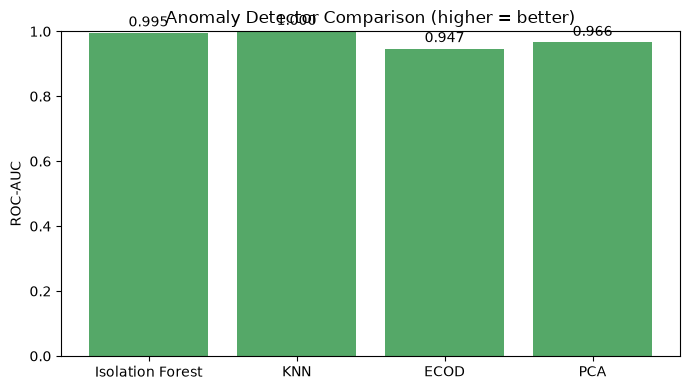

In [17]:
names = list(results.keys())
aucs = [results[n]["auc"] for n in names]

plt.figure(figsize=(7, 4))
bars = plt.bar(names, aucs, color="#55A868")
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Anomaly Detector Comparison (higher = better)")
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, auc + 0.02, f"{auc:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 5. Visualize predictions vs ground truth

Side-by-side: what the model *flagged* as anomalous vs what *actually* was anomalous.

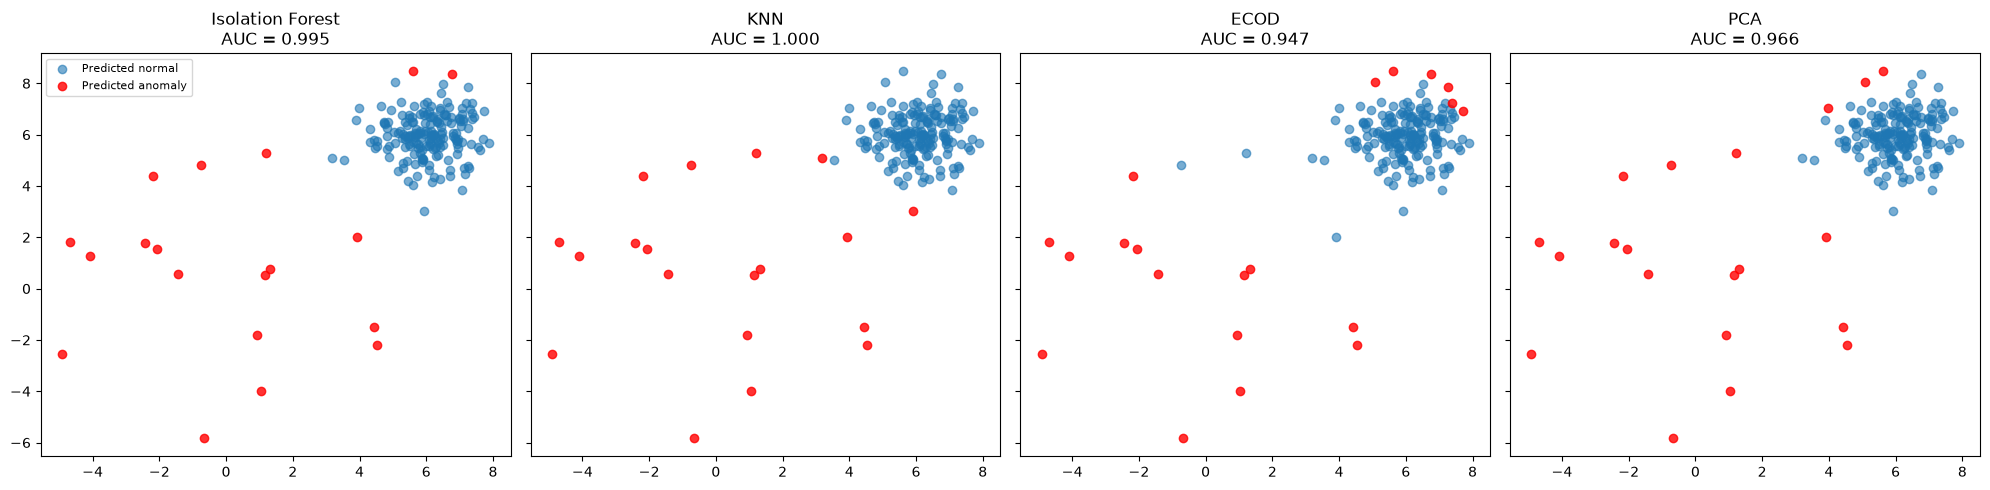

In [18]:
fig, axes = plt.subplots(1, len(detectors), figsize=(5 * len(detectors), 5), sharex=True, sharey=True)

for ax, name in zip(axes, names):
    pred = results[name]["pred"]
    ax.scatter(X_test[pred == 0, 0], X_test[pred == 0, 1], label="Predicted normal", alpha=0.6)
    ax.scatter(X_test[pred == 1, 0], X_test[pred == 1, 1], label="Predicted anomaly", color="red", alpha=0.8)
    ax.set_title(f"{name}\nAUC = {results[name]['auc']:.3f}")

axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()